In [34]:
# Read csv into pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Had to remove manually the first two lines since they where 2 elements long
df_untouched = pd.read_csv('API_14_DS2_en_csv_v2_580578.csv')

In [35]:
# Make a copy of the untouched DataFrame
df = df_untouched.copy()

# Selection of countries
countries = ['Italy', 'Switzerland', 'France', 'Poland']
df = df[df['Country Name'].isin(countries)]
# Selection of years
years = [str(year) for year in range(2002, 2025)]
df = df[['Country Name', 'Indicator Code'] + years]

# Selection of columns
# "Technicians in R&D (per million people)","SP.POP.TECH.RD.P6"
# "Researchers in R&D (per million people)","SP.POP.SCIE.RD.P6"
# "Research and development expenditure (% of GDP)","GB.XPD.RSDV.GD.ZS"
df_tech = df[df['Indicator Code'] == 'SP.POP.TECH.RD.P6']
# drop the indicator code column since it's the same for all rows
df_tech = df_tech.drop(columns=['Indicator Code'])
df_research = df[df['Indicator Code'] == 'SP.POP.SCIE.RD.P6']
df_research = df_research.drop(columns=['Indicator Code'])
df_expenditure = df[df['Indicator Code'] == 'GB.XPD.RSDV.GD.ZS']
df_expenditure = df_expenditure.drop(columns=['Indicator Code'])

In [36]:
# Save to a new CSV file
df_research.to_csv('Researchers_in_R&D.csv', index=False)
df_expenditure.to_csv('R&D_Expenditure_percentage_of_GDP.csv', index=False)

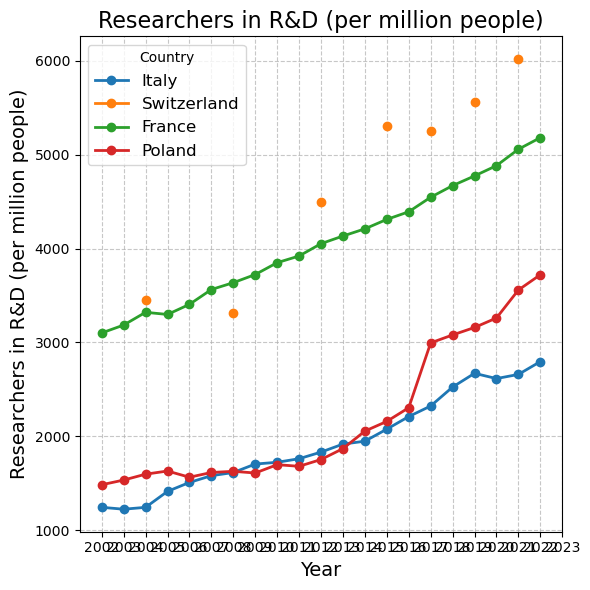

Weights: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
     Country Name  Weighted Average         2022
373   Switzerland       5236.179714          NaN
773        France       4398.704494  5181.845703
1163        Italy       2201.250622  2795.534180
1903       Poland       2559.502122  3721.072021


In [37]:
plt.figure(figsize=(6, 6))
for country in countries:
    data = df_research[df_research['Country Name'] == country].iloc[0, 1:]
    plt.plot(years, data, marker='o', label=country, linewidth=2)
plt.title('Researchers in R&D (per million people)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Researchers in R&D (per million people)', fontsize=14)
plt.legend(title='Country', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Weighted average with increasing weights for more recent years
df = df_research.copy()
weights = np.arange(1, len(years) + 1)
print("Weights:", weights)
df['Weighted Average'] = df[years].apply(lambda row: np.average(row.dropna(), weights=weights[:len(row.dropna())]), axis=1)
print(df[['Country Name', 'Weighted Average', '2022']])


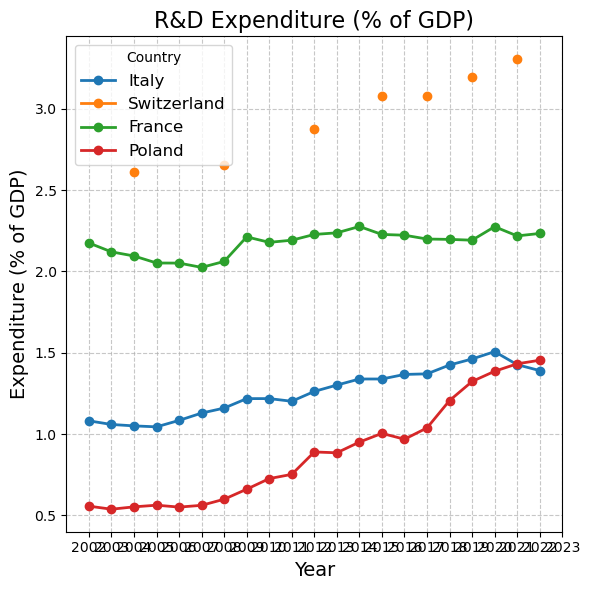

Weights: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
     Country Name  Weighted Average     2022
377   Switzerland          3.091498      NaN
777        France          2.202813  2.23312
1167        Italy          1.335441  1.39014
1907       Poland          1.051916  1.45383


In [38]:
plt.figure(figsize=(6, 6))
for country in countries:
    data = df_expenditure[df_expenditure['Country Name'] == country].iloc[0, 1:]
    plt.plot(years, data, marker='o', label=country, linewidth=2)
plt.title('R&D Expenditure (% of GDP)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Expenditure (% of GDP)', fontsize=14)
plt.legend(title='Country', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Weighted average with increasing weights for more recent years
df = df_expenditure.copy()
weights = np.arange(1, len(years) + 1)
print("Weights:", weights)
df['Weighted Average'] = df[years].apply(lambda row: np.average(row.dropna(), weights=weights[:len(row.dropna())]), axis=1)
print(df[['Country Name', 'Weighted Average', '2022']])